# 1. Project Overview

## NEXUS Person Follower Robot — YOLO Person Detection Model Development

**NEXUS** is an autonomous mobile robot inspired by *Karen from SpongeBob SquarePants*, developed at the **Technology and Information Department of Brawijaya University**. The robot's primary objective is to interact with humans, authenticate a user through an open-palm gesture password, lock onto that individual, and autonomously follow them using a three-wheel differential drive platform while maintaining a safe target distance.

---

### Notebook Scope & System Boundary

The scope of this notebook is strictly isolated to **YOLO Person Detection Model Development**:

```text
Image / Camera Frame
        ↓
       YOLO
        ↓
Person Detection
        ↓
Bounding Boxes + Confidence (PersonDetection[])
```

```
+-----------------------------------------------------------------------------+
|                            NEXUS VISION PIPELINE                            |
|                                                                             |
|  +-----------------------------------------------------------------------+  |
|  |                    THIS NOTEBOOK'S STRICT SCOPE                       |  |
|  |                                                                       |  |
|  |   [ Camera Frame ] ---> [ YOLO Object Detector ] ---> [ Filter: person ]|
|  |                                                             |         |  |
|  |                                                             v         |  |
|  |                                                   [ PersonDetection[] ]|  |
|  +-------------------------------------------------------------|---------+  |
|                                                                |            |
|  ==============================================================|==========  |
|                         DOWNSTREAM MODULES                     |            |
|                    (Out of scope for this notebook)            v            |
|                                                      [ Person Tracking ]    |
|                                                      (ByteTrack/BoT-SORT)   |
|                                                                |            |
|   [ Hand Gesture Recognition ] ---> [ Gesture-Person Assoc ]   |            |
|          (MediaPipe Palm)                       |              |            |
|                                                 v              v            |
|                                          [ Authentication / Target Lock ]   |
|                                                                |            |
|                                                                v            |
|                                                    [ Follow Controller ]    |
|                                                                |            |
|                                                                v            |
|                                                      [ ESP32 Motor Driver ] |
+-----------------------------------------------------------------------------+
```

### Key Architectural Rules
1. **Person Detection Only**: The model filters detections strictly to the `person` class.
2. **Decoupled Output**: Detection outputs are converted to a clean, framework-agnostic data structure (`PersonDetection`), ensuring downstream modules do not depend on Ultralytics-specific objects.
3. **Hardware Lifecycle**: Development occurs on the development laptop (GPU/CPU), producing exported models for eventual deployment on **Raspberry Pi 5**.
4. **Development Artifact**: This notebook is an unexecuted development tool. Cells are executed only when development or benchmarking is intentionally performed.


# 2. Documentation Reference

This notebook adheres directly to the NEXUS architectural and engineering specifications:

| Document Path | Key Topic & Relevance |
| :--- | :--- |
| `docs/1_concept/general_concept.md` | Section 1 (Overview), Section 3 (Architecture), Section 14 (Target Tracking) |
| `docs/1_concept/requirement_file_top_level.md` | Section 4 (Computer Vision Requirements, YOLO specification) |
| `docs/2_system_design/system_architecture.md` | Section 5 (Perception Layer, YOLO detector specification) |
| `docs/2_system_design/data_flow.md` | Section 4 (`Camera -> Person Detection -> PersonDetection[]`) |
| `docs/2_system_design/subsystem_design.md` | Section 3 (Perception Subsystem Design) |
| `docs/3_software_design/software_architecture.md` | Section 3 (Layer Architecture), Section 16 (Inter-Module Communication) |
| `docs/3_software_design/module_specification.md` | **Section 6 (`vision/person_detection.py`)** & Section 7 (`person_tracking.py`) |
| `docs/3_software_design/interface_spesification.md` | **Section 3.1 (`PersonDetection` data structure specification)** |
| `docs/3_software_design/configuration_spesification.md` | **Section 4 (Person Detection Configuration: confidence, intervals)** |
| `docs/5_validation/acceptance_criteria.md` | Section 5 (AC-003: Person Detection Acceptance Criteria) |
| `docs/5_validation/tes_plan.md` | Section 3 (Software Test Environment) & Integration test flows |

All variables, data classes, and coordinate conventions used herein directly reflect these documents.


# 3. Environment Setup

This section verifies the local development environment, reporting versions of core packages (PyTorch, Ultralytics, OpenCV, NumPy) and detecting hardware acceleration (NVIDIA CUDA GPU vs. CPU fallback).

The notebook automatically selects:
- `cuda:0` if an NVIDIA GPU is available with CUDA support.
- `cpu` otherwise.

> [!TIP]
> If `ultralytics` or `onnxruntime` is not installed in your Python environment, install them with:
> ```bash
> pip install ultralytics onnx onnxruntime
> ```


In [1]:
# Optional dependency installation check
# To install missing packages directly from this notebook, uncomment the line below:
# !pip install ultralytics onnx onnxruntime matplotlib

import sys
import os
import platform
from pathlib import Path
import numpy as np
import cv2
import torch

try:
    import ultralytics
    from ultralytics import YOLO
    ULTRALYTICS_AVAILABLE = True
except ImportError:
    ULTRALYTICS_AVAILABLE = False

print("=" * 60)
print("NEXUS PERSON FOLLOWER ROBOT — ENVIRONMENT AUDIT")
print("=" * 60)
print(f"OS Platform         : {platform.system()} {platform.release()} ({platform.machine()})")
print(f"Python Version      : {sys.version.split()[0]}")
print(f"PyTorch Version     : {torch.__version__}")
print(f"OpenCV Version      : {cv2.__version__}")
print(f"NumPy Version       : {np.__version__}")
if ULTRALYTICS_AVAILABLE:
    print(f"Ultralytics Version : {ultralytics.__version__}")
else:
    print("Ultralytics Version : NOT INSTALLED")
    print("                      [ACTION REQUIRED] Run in terminal or a notebook cell:")
    print("                      pip install ultralytics onnx onnxruntime")

# Hardware acceleration detection
CUDA_AVAILABLE = torch.cuda.is_available()
if CUDA_AVAILABLE:
    DEVICE = "cuda:0"
    GPU_NAME = torch.cuda.get_device_name(0)
    DEVICE_COUNT = torch.cuda.device_count()
    print(f"Acceleration Device : CUDA GPU ({GPU_NAME})")
    print(f"CUDA Device Count   : {DEVICE_COUNT}")
else:
    DEVICE = "cpu"
    print("Acceleration Device : CPU (No CUDA GPU detected; running in CPU mode)")
print("=" * 60)


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/nexus_is/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
NEXUS PERSON FOLLOWER ROBOT — ENVIRONMENT AUDIT
OS Platform         : Linux 7.0.0-31-generic (x86_64)
Python Version      : 3.10.20
PyTorch Version     : 2.5.1
OpenCV Version      : 4.12.0
NumPy Version       : 2.2.6
Ultralytics Version : 8.4.142
Acceleration Device : CPU (No CUDA GPU detected; running in CPU mode)


# 4. Configuration

A centralized configuration section containing all hyperparameters, paths, and flags. Paths are defined relative to the notebook location (`models/yolo/`).

### Configuration Parameters:
- `IMAGE_SIZE`: YOLO input resolution (default $640 \times 640$).
- `CONFIDENCE_THRESHOLD`: Minimum confidence score for person detections (default `0.50` per `docs/3_software_design/configuration_spesification.md`).
- `IOU_THRESHOLD`: Non-Maximum Suppression (NMS) intersection-over-union threshold (default `0.45`).
- `MODEL_NAME`: Target lightweight YOLO architecture (default `yolov8n.pt`).
- `TRAIN_MODEL`: Safety flag for custom dataset training (disabled by default: `False`).
- `EXPORT_FP16`: Toggle for FP16 half-precision model export (default: `False`).
- `EXPORT_INT8`: Toggle for INT8 quantized model export (default: `False`).
- `ENABLE_WEBCAM`: Toggle for optional live webcam inference (default: `False`).


In [2]:
from dataclasses import dataclass
from pathlib import Path

# Base Paths (Relative to this notebook in models/yolo/)
NOTEBOOK_DIR = Path.cwd().resolve() if Path.cwd().name == "yolo" else Path("models/yolo").resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

# Centralized Directory Paths
DATASETS_DIR = NOTEBOOK_DIR / "datasets"
PERSON_DATASET_DIR = DATASETS_DIR / "person"
WEIGHTS_DIR = NOTEBOOK_DIR / "weights"
RUNS_DIR = NOTEBOOK_DIR / "runs"
EXPORTS_DIR = NOTEBOOK_DIR / "exports"

# Detection Hyperparameters (per docs/3_software_design/configuration_spesification.md)
IMAGE_SIZE: int = 640
CONFIDENCE_THRESHOLD: float = 0.50
IOU_THRESHOLD: float = 0.45

# Model Architecture Choice
MODEL_NAME: str = "yolov8n.pt"
BASELINE_WEIGHTS_PATH = WEIGHTS_DIR / MODEL_NAME

# Operational Toggles (All training & export optimizations disabled by default)
TRAIN_MODEL: bool = False
EXPORT_FP16: bool = False
EXPORT_INT8: bool = False
ENABLE_WEBCAM: bool = False

print("Centralized Configuration Initialized:")
print(f"  Notebook Dir      : {NOTEBOOK_DIR}")
print(f"  Model Name        : {MODEL_NAME}")
print(f"  Image Size        : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Confidence Thresh : {CONFIDENCE_THRESHOLD}")
print(f"  IoU Threshold     : {IOU_THRESHOLD}")
print(f"  Train Model Flag  : {TRAIN_MODEL}")
print(f"  Export FP16 Flag  : {EXPORT_FP16}")
print(f"  Export INT8 Flag  : {EXPORT_INT8}")


Centralized Configuration Initialized:
  Notebook Dir      : /home/nexus_is/NEXUS_Person_Follower_Robot/models/yolo
  Model Name        : yolov8n.pt
  Image Size        : 640x640
  Confidence Thresh : 0.5
  IoU Threshold     : 0.45
  Train Model Flag  : False
  Export FP16 Flag  : False
  Export INT8 Flag  : False


# 5. Directory Setup

Prepares and verifies the local workspace directory structure under `models/yolo/`:

```text
models/yolo/
├── yolo_person_detection.ipynb  <- This notebook
├── datasets/                    <- Custom person datasets
│   └── person/
│       ├── images/ {train, val, test}
│       └── labels/ {train, val, test}
├── weights/                     <- Downloaded / baseline pretrained weights
├── runs/                        <- Training experiment outputs & logs
└── exports/                     <- Final exported models (PT, ONNX) & model_info.json
```


In [3]:
# Initialize directories
directories = [
    DATASETS_DIR,
    PERSON_DATASET_DIR,
    WEIGHTS_DIR,
    RUNS_DIR,
    EXPORTS_DIR,
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Directory structure verified:")
for directory in directories:
    status = "EXISTS" if directory.exists() else "MISSING"
    print(f"  [{status}] {directory.relative_to(PROJECT_ROOT) if PROJECT_ROOT in directory.parents else directory}")


Directory structure verified:
  [EXISTS] models/yolo/datasets
  [EXISTS] models/yolo/datasets/person
  [EXISTS] models/yolo/weights
  [EXISTS] models/yolo/runs
  [EXISTS] models/yolo/exports


# 6. YOLO Model Selection

### Strategic Architecture Rationale

For the NEXUS Person Follower Robot, the object detector must eventually run in real-time alongside tracking and hand gesture recognition on a **Raspberry Pi 5**. The computational budget is constrained:

| Architecture | Params | FLOPs (640) | Inference Target | Suitability for Raspberry Pi 5 |
| :--- | :---: | :---: | :---: | :--- |
| **YOLOv8n (Nano)** | **~3.2M** | **~8.7 GFLOPs** | Edge / Embedded | **Primary Candidate**: High FPS, low thermal footprint |
| **YOLOv8s (Small)** | ~11.2M | ~28.6 GFLOPs | Mobile / Desktop | Secondary Candidate: Better recall, heavier load |
| **YOLOv8m (Medium)** | ~25.9M | ~78.9 GFLOPs | Desktop GPU | Exceeds real-time budget on CPU without dedicated NPU |

### Development Workflow Strategy:
```text
Pretrained YOLO (COCO)
        ↓
Baseline Evaluation on Human Subjects
        ↓
Determine whether custom training is needed (domain gap check)
        ↓
[Optional] Custom Training (Fine-tuning on person dataset)
        ↓
Evaluation & Benchmark Comparison
        ↓
Final Model Selection
        ↓
Export to PyTorch (.pt) & ONNX (.onnx)
```

We select `yolov8n.pt` as our primary baseline model candidate.


In [4]:
# Model Selection Specification
SELECTED_MODEL_FAMILY = "YOLOv8"
SELECTED_MODEL_SCALE = "nano (n)"
SELECTED_MODEL_WEIGHTS = MODEL_NAME

print(f"Selected Architecture : {SELECTED_MODEL_FAMILY} ({SELECTED_MODEL_SCALE})")
print(f"Weights Specifier     : {SELECTED_MODEL_WEIGHTS}")
print("Baseline Pretrained Dataset: MS COCO (80 classes, class 0 = person)")


Selected Architecture : YOLOv8 (nano (n))
Weights Specifier     : yolov8n.pt
Baseline Pretrained Dataset: MS COCO (80 classes, class 0 = person)


# 7. Load Pretrained Model

This section loads the selected YOLO model, verifies its task type (`detect`), checks its class mapping, and dynamically resolves the exact class ID corresponding to `person`.

> [!NOTE]
> In standard MS COCO, class `0` is `'person'`. Rather than hardcoding this assumption blindly, the code dynamically queries the model's `names` dictionary.


In [5]:
def load_pretrained_yolo(model_name_or_path: str, weights_dir: Path):
    """
    Instantiate YOLO model from local weights directory or default Ultralytics repository.
    Verifies model task and dynamically identifies the 'person' class ID.
    """
    if not ULTRALYTICS_AVAILABLE:
        print("[WARNING] Ultralytics is not installed. Please run: pip install ultralytics")
        return None, 0

    local_path = weights_dir / model_name_or_path
    load_target = str(local_path) if local_path.exists() else model_name_or_path

    print(f"Loading YOLO model from: {load_target}...")
    model = YOLO(load_target)

    # Inspect class names mapping
    names_dict = model.names
    person_class_id = None
    for cls_id, cls_name in names_dict.items():
        if cls_name.lower() == "person":
            person_class_id = int(cls_id)
            break

    if person_class_id is None:
        raise ValueError("Could not locate 'person' class in model class dictionary!")

    print(f"Model Task        : {getattr(model, 'task', 'detect')}")
    print(f"Total Classes     : {len(names_dict)}")
    print(f"Person Class ID   : {person_class_id} ('{names_dict[person_class_id]}')")
    return model, person_class_id

# Instantiate model
model, person_class_id = load_pretrained_yolo(MODEL_NAME, WEIGHTS_DIR)


Loading YOLO model from: yolov8n.pt...
Model Task        : detect
Total Classes     : 80
Person Class ID   : 0 ('person')


# 8. PersonDetection Data Structure

To ensure complete decoupling between the Ultralytics detection framework and the rest of the NEXUS software architecture, we define `@dataclass PersonDetection`.

This definition is strictly aligned with:
- `docs/3_software_design/interface_spesification.md` Section 3.1
- `docs/3_software_design/module_specification.md` Section 6

```text
PersonDetection
├── bbox: (x1, y1, x2, y2)   [int pixel coordinates]
├── confidence: float         [0.0 to 1.0]
└── class_id: int             [detector class ID]
```


In [6]:
from dataclasses import dataclass
from typing import Tuple, List

@dataclass
class PersonDetection:
    """
    Represents a detected person in an image frame.
    Strictly adheres to docs/3_software_design/interface_spesification.md Section 3.1.

    Attributes:
        bbox (tuple[int, int, int, int]): Bounding box (x1, y1, x2, y2) in pixel coordinates.
        confidence (float): Detection confidence score in [0.0, 1.0].
        class_id (int): Detector class identifier (person class ID).
    """
    bbox: Tuple[int, int, int, int]
    confidence: float
    class_id: int

    @property
    def x1(self) -> int:
        return self.bbox[0]

    @property
    def y1(self) -> int:
        return self.bbox[1]

    @property
    def x2(self) -> int:
        return self.bbox[2]

    @property
    def y2(self) -> int:
        return self.bbox[3]

    @property
    def width(self) -> int:
        """Bounding box width in pixels."""
        return max(0, self.x2 - self.x1)

    @property
    def height(self) -> int:
        """Bounding box height in pixels."""
        return max(0, self.y2 - self.y1)

    @property
    def center(self) -> Tuple[float, float]:
        """
        Bounding-box centroid (xc, yc) in pixel coordinates.
        Used by the NEXUS center controller (docs/1_concept/general_concept.md Section 15).
        """
        return ((self.x1 + self.x2) / 2.0, (self.y1 + self.y2) / 2.0)

    @property
    def area(self) -> int:
        """Bounding box pixel area."""
        return self.width * self.height

    def to_dict(self) -> dict:
        """Serialize to standard dictionary."""
        return {
            "bbox": list(self.bbox),
            "confidence": round(float(self.confidence), 4),
            "class_id": int(self.class_id),
            "center": [round(c, 2) for c in self.center],
            "area": self.area
        }

# Verify data structure with a sample test instance
sample_det = PersonDetection(bbox=(100, 150, 300, 500), confidence=0.925, class_id=0)
print("PersonDetection data structure registered successfully.")
print(f"Sample detection verification: center={sample_det.center}, width={sample_det.width}, height={sample_det.height}")


PersonDetection data structure registered successfully.
Sample detection verification: center=(200.0, 325.0), width=200, height=350


# 9. Person Detection Function

The core reusable detection function `detect_persons(frame, ...)`:
- Accepts a raw BGR image/frame (OpenCV format).
- Executes YOLO inference at the configured input resolution.
- Filters output strictly for detections matching the designated `person_class_id`.
- Applies `CONFIDENCE_THRESHOLD` and `IOU_THRESHOLD`.
- Converts raw bounding boxes to integer `(x1, y1, x2, y2)` pixel coordinates.
- Returns a list of `PersonDetection` objects.


In [7]:
def detect_persons(
    frame: np.ndarray,
    model,
    conf_threshold: float = CONFIDENCE_THRESHOLD,
    iou_threshold: float = IOU_THRESHOLD,
    img_size: int = IMAGE_SIZE,
    device: str = DEVICE,
    person_class_id: int = 0
) -> List[PersonDetection]:
    """
    Detect human persons in an input frame using YOLO.

    Args:
        frame (np.ndarray): BGR image frame (H, W, 3).
        model: Loaded YOLO model instance.
        conf_threshold (float): Minimum confidence threshold (default 0.50).
        iou_threshold (float): NMS IoU threshold (default 0.45).
        img_size (int): Inference image dimension (default 640).
        device (str): Computation device ('cuda:0' or 'cpu').
        person_class_id (int): Model class ID corresponding to 'person'.

    Returns:
        List[PersonDetection]: List of detected persons matching interface specification.
    """
    if model is None:
        print("[NOTICE] Model not loaded. detect_persons() cannot execute without a loaded model.")
        return []

    if frame is None or frame.size == 0:
        return []

    # Run inference without verbose logging
    results = model(
        frame,
        conf=conf_threshold,
        iou=iou_threshold,
        imgsz=img_size,
        device=device,
        classes=[person_class_id],
        verbose=False
    )

    detections: List[PersonDetection] = []
    if not results:
        return detections

    first_result = results[0]
    if first_result.boxes is None:
        return detections

    boxes = first_result.boxes
    for box in boxes:
        cls_id = int(box.cls[0].item())
        conf = float(box.conf[0].item())

        # Verify class match
        if cls_id != person_class_id:
            continue

        # Extract coordinates (x1, y1, x2, y2)
        xyxy = box.xyxy[0].tolist()
        x1 = max(0, int(round(xyxy[0])))
        y1 = max(0, int(round(xyxy[1])))
        x2 = min(frame.shape[1], int(round(xyxy[2])))
        y2 = min(frame.shape[0], int(round(xyxy[3])))

        # Ensure valid box dimensions
        if x2 > x1 and y2 > y1:
            detections.append(PersonDetection(
                bbox=(x1, y1, x2, y2),
                confidence=conf,
                class_id=cls_id
            ))

    return detections

print("Reusable detect_persons() function defined.")


Reusable detect_persons() function defined.


# 10. Image Inference

Executes person detection on a single still image. If no custom image is supplied, a synthetic test frame is generated to ensure safe end-to-end code path validation without external network dependencies.


In [8]:
def run_single_image_inference(
    image_path: Path,
    model,
    conf_threshold: float = CONFIDENCE_THRESHOLD,
    person_class_id: int = 0
) -> Tuple[np.ndarray, List[PersonDetection]]:
    """
    Loads an image from file (or creates synthetic test canvas) and runs person detection.
    """
    if not image_path.exists():
        print(f"[INFO] Image file '{image_path.name}' not found. Generating a synthetic test canvas.")
        # Create a neutral synthetic test canvas (640x640 BGR)
        frame = np.full((640, 640, 3), 200, dtype=np.uint8)
        # Draw a synthetic human silhouette placeholder
        cv2.circle(frame, (320, 200), 50, (120, 120, 120), -1)  # Head
        cv2.ellipse(frame, (320, 380), (80, 140), 0, 0, 360, (120, 120, 120), -1)  # Body
        cv2.putText(
            frame, "NEXUS Test Canvas (Synthetic Target)",
            (80, 580), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (50, 50, 50), 2
        )
    else:
        frame = cv2.imread(str(image_path))
        if frame is None:
            raise ValueError(f"Could not decode image at: {image_path}")

    detections = detect_persons(
        frame=frame,
        model=model,
        conf_threshold=conf_threshold,
        person_class_id=person_class_id
    )

    print(f"Inference complete: {len(detections)} person(s) detected.")
    for idx, det in enumerate(detections, start=1):
        print(f"  Person #{idx}: bbox={det.bbox}, conf={det.confidence:.2%}, center={det.center}")

    return frame, detections

# Execute image inference
sample_img_path = NOTEBOOK_DIR / "sample_test.jpg"
test_frame, detections = run_single_image_inference(
    image_path=sample_img_path,
    model=model,
    conf_threshold=CONFIDENCE_THRESHOLD,
    person_class_id=person_class_id
)


[INFO] Image file 'sample_test.jpg' not found. Generating a synthetic test canvas.
Inference complete: 0 person(s) detected.


# 11. Detection Visualization

Renders person detections onto the image frame according to NEXUS HMI conventions:
- **Bounding Box**: High-visibility boundary around the detected person.
- **Label**: Class tag `person` and formatted confidence percentage (e.g. `person: 88.5%`).
- **Header HUD**: Total person count indicator (`Persons: N`) in the upper corner.
- **Center Marker**: Small crosshair at the bounding-box centroid $(x_c, y_c)$ for visual tracking alignment.


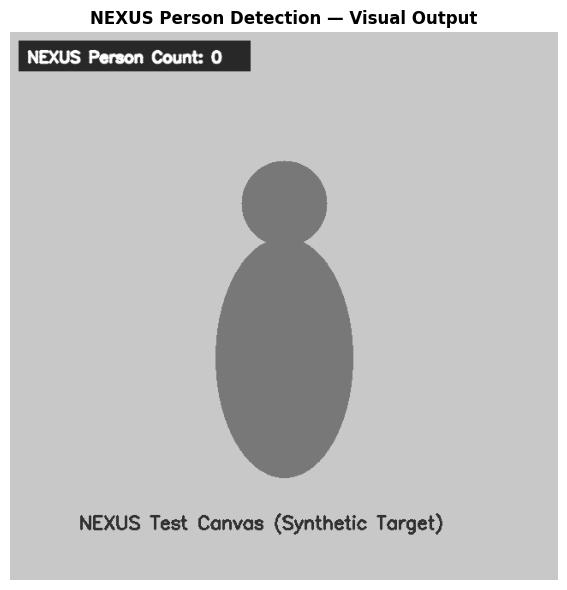

In [9]:
import matplotlib.pyplot as plt

def draw_person_detections(
    frame: np.ndarray,
    detections: List[PersonDetection],
    box_color: Tuple[int, int, int] = (0, 255, 0),
    text_color: Tuple[int, int, int] = (0, 0, 0),
    thickness: int = 2
) -> np.ndarray:
    """
    Render bounding boxes, labels, centroid markers, and count HUD on an image frame.
    """
    canvas = frame.copy()
    height, width = canvas.shape[:2]

    # Draw each person detection
    for det in detections:
        x1, y1, x2, y2 = det.bbox
        # Bounding box
        cv2.rectangle(canvas, (x1, y1), (x2, y2), box_color, thickness)

        # Centroid crosshair
        cx, cy = int(det.center[0]), int(det.center[1])
        cv2.drawMarker(canvas, (cx, cy), (0, 0, 255), cv2.MARKER_CROSS, 12, 2)

        # Label tag
        label = f"person: {det.confidence:.1%}"
        font_scale = 0.5
        (lw, lh), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, 1)
        tag_y1 = max(0, y1 - lh - baseline - 4)
        tag_y2 = y1
        cv2.rectangle(canvas, (x1, tag_y1), (x1 + lw + 6, tag_y2), box_color, -1)
        cv2.putText(
            canvas, label, (x1 + 3, tag_y2 - baseline - 2),
            cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, 1, cv2.LINE_AA
        )

    # Top HUD Banner: Detected Persons Count
    banner_text = f"NEXUS Person Count: {len(detections)}"
    cv2.rectangle(canvas, (10, 10), (280, 45), (40, 40, 40), -1)
    cv2.putText(
        canvas, banner_text, (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA
    )
    return canvas

def display_inline_image(frame_bgr: np.ndarray, title: str = "NEXUS Person Detection"):
    """Convert BGR to RGB and render inline using matplotlib."""
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(9, 6))
    plt.imshow(frame_rgb)
    plt.title(title, fontsize=12, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Render visualization on test frame
annotated_frame = draw_person_detections(test_frame, detections)
display_inline_image(annotated_frame, title="NEXUS Person Detection — Visual Output")


# 12. Video Inference

Processes video files or optional live camera streams frame-by-frame:
- Computes per-frame inference latency (ms).
- Measures rolling Frames Per Second (FPS).
- Overlays real-time performance metrics on each frame.
- Safely terminates on key press (`'q'`) or upon reaching `max_frames`.


In [10]:
import time

def process_video_feed(
    video_source,
    model,
    conf_threshold: float = CONFIDENCE_THRESHOLD,
    max_frames: int = 60,
    output_path: Path = None,
    person_class_id: int = 0
):
    """
    Process a video file or live camera stream.
    """
    if model is None:
        print("[NOTICE] Model not loaded. Skipping video feed.")
        return

    cap = cv2.VideoCapture(video_source)
    if not cap.isOpened():
        print(f"[ERROR] Could not open video source: {video_source}")
        return

    writer = None
    if output_path is not None:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    frame_count = 0
    print(f"Starting video processing (Source: {video_source}, Max Frames: {max_frames})...")

    try:
        while cap.isOpened() and frame_count < max_frames:
            ret, frame = cap.read()
            if not ret or frame is None:
                break

            t_start = time.perf_counter()
            detections = detect_persons(
                frame=frame,
                model=model,
                conf_threshold=conf_threshold,
                person_class_id=person_class_id
            )
            t_latency_ms = (time.perf_counter() - t_start) * 1000.0
            fps_estimate = 1000.0 / t_latency_ms if t_latency_ms > 0 else 0.0

            annotated_frame = draw_person_detections(frame, detections)

            # Performance telemetry overlay
            telemetry_str = f"Latency: {t_latency_ms:.1f} ms | FPS: {fps_estimate:.1f}"
            cv2.putText(
                annotated_frame, telemetry_str, (15, annotated_frame.shape[0] - 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 255), 2, cv2.LINE_AA
            )

            if writer is not None:
                writer.write(annotated_frame)

            frame_count += 1

    finally:
        cap.release()
        if writer is not None:
            writer.release()
        print(f"Video processing finished. Processed {frame_count} frames.")

# Video inference check
if ENABLE_WEBCAM:
    process_video_feed(video_source=0, model=model, max_frames=50, person_class_id=person_class_id)
else:
    print("[INFO] Video/Webcam inference skipped (ENABLE_WEBCAM = False).")
    print("       To test with live webcam, set ENABLE_WEBCAM = True in Section 4.")


[INFO] Video/Webcam inference skipped (ENABLE_WEBCAM = False).
       To test with live webcam, set ENABLE_WEBCAM = True in Section 4.


# 13. Dataset Preparation

If domain-specific fine-tuning is required (e.g. specialized robot perspective, low camera angles, or specific indoor lighting at Brawijaya University), the custom dataset must be organized according to the standard YOLO directory structure:

```text
datasets/
└── person/
    ├── dataset.yaml
    ├── images/
    │   ├── train/
    │   ├── val/
    │   └── test/
    └── labels/
        ├── train/
        ├── val/
        └── test/
```

### YOLO Annotation Format
Each image has a corresponding `.txt` file containing one line per labeled person:
```text
<class_id> <x_center> <y_center> <width> <height>
```
Where:
- `class_id` is always `0` (`person`).
- `x_center, y_center, width, height` are normalized floats in $[0.0, 1.0]$.


In [11]:
def generate_dataset_yaml(dataset_dir: Path, output_yaml_path: Path) -> Path:
    """
    Generates dataset.yaml with relative path mappings for Ultralytics YOLO.
    """
    yaml_content = f"""# NEXUS Person Follower Robot — Custom Person Dataset Configuration
path: {dataset_dir.as_posix()}
train: images/train
val: images/val
test: images/test

# Classes
names:
  0: person
"""
    output_yaml_path.parent.mkdir(parents=True, exist_ok=True)
    output_yaml_path.write_text(yaml_content)
    print(f"Generated dataset specification: {output_yaml_path}")
    return output_yaml_path

DATASET_YAML_PATH = PERSON_DATASET_DIR / "dataset.yaml"
generate_dataset_yaml(PERSON_DATASET_DIR, DATASET_YAML_PATH)


Generated dataset specification: /home/nexus_is/NEXUS_Person_Follower_Robot/models/yolo/datasets/person/dataset.yaml


PosixPath('/home/nexus_is/NEXUS_Person_Follower_Robot/models/yolo/datasets/person/dataset.yaml')

# 14. Dataset Validation

Before executing any training, the dataset must pass integrity audits:
- **Pairing Check**: Every image must have a corresponding label file, and vice-versa.
- **Coordinate Bounds**: $0.0 \le x_c, y_c, w, h \le 1.0$.
- **Dimension Check**: $w > 0$ and $h > 0$.
- **Class ID Validation**: `class_id == 0`.
- **Empty File Audit**: Warns about zero-label images (background negatives).
- **Split Balance**: Summarizes image and instance counts across `train`, `val`, and `test`.


In [12]:
def validate_person_dataset(dataset_dir: Path) -> dict:
    """
    Audits the custom YOLO person dataset for structural integrity.
    """
    report = {
        "dataset_exists": dataset_dir.exists(),
        "splits": {},
        "issues": []
    }

    if not dataset_dir.exists():
        report["issues"].append(f"Dataset directory '{dataset_dir}' does not exist.")
        print(f"[STATUS] {report['issues'][-1]}")
        print("  Notice: Custom dataset has not been created yet. Skipping validation.")
        return report

    image_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    splits = ["train", "val", "test"]

    for split in splits:
        img_dir = dataset_dir / "images" / split
        lbl_dir = dataset_dir / "labels" / split

        if not img_dir.exists():
            report["splits"][split] = {"status": "NOT_POPULATED", "images": 0, "labels": 0, "instances": 0}
            continue

        images = [p for p in img_dir.iterdir() if p.suffix.lower() in image_exts]
        labels = list(lbl_dir.iterdir()) if lbl_dir.exists() else []

        instance_count = 0
        split_issues = []

        for img_path in images:
            lbl_path = lbl_dir / f"{img_path.stem}.txt"
            if not lbl_path.exists():
                split_issues.append(f"Missing label file for image: {img_path.name}")
                continue

            lines = lbl_path.read_text().strip().splitlines()
            for line_idx, line in enumerate(lines, start=1):
                parts = line.strip().split()
                if len(parts) != 5:
                    split_issues.append(f"{lbl_path.name} line {line_idx}: Expected 5 values, got {len(parts)}")
                    continue

                cls_id, xc, yc, w, h = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                if cls_id != 0:
                    split_issues.append(f"{lbl_path.name} line {line_idx}: Invalid class_id {cls_id} (must be 0)")
                if not (0.0 <= xc <= 1.0 and 0.0 <= yc <= 1.0 and 0.0 <= w <= 1.0 and 0.0 <= h <= 1.0):
                    split_issues.append(f"{lbl_path.name} line {line_idx}: Coordinates out of [0, 1] bounds")
                if w <= 0.0 or h <= 0.0:
                    split_issues.append(f"{lbl_path.name} line {line_idx}: Non-positive box width/height")

                instance_count += 1

        report["splits"][split] = {
            "status": "VALID" if not split_issues else "HAS_ISSUES",
            "images": len(images),
            "labels": len(labels),
            "instances": instance_count,
            "issues": split_issues[:5]
        }

    # Print summary report
    print("=" * 60)
    print("NEXUS DATASET INTEGRITY REPORT")
    print("=" * 60)
    for split, info in report["splits"].items():
        print(f"Split [{split:5s}]: {info['images']} images | {info['instances']} person instances | Status: {info['status']}")
    print("=" * 60)
    return report

# Run dataset audit
dataset_audit = validate_person_dataset(PERSON_DATASET_DIR)


NEXUS DATASET INTEGRITY REPORT
Split [train]: 0 images | 0 person instances | Status: NOT_POPULATED
Split [val  ]: 0 images | 0 person instances | Status: NOT_POPULATED
Split [test ]: 0 images | 0 person instances | Status: NOT_POPULATED


# 15. Dataset Visualization

Visualizes randomly sampled training images along with their ground-truth bounding box annotations to confirm annotation quality and coordinate transformations prior to training.


In [13]:
import random

def visualize_dataset_samples(dataset_dir: Path, split: str = "train", num_samples: int = 3):
    """
    Plots random ground-truth annotated samples from the dataset.
    """
    img_dir = dataset_dir / "images" / split
    lbl_dir = dataset_dir / "labels" / split

    if not img_dir.exists():
        print(f"[NOTICE] Dataset split '{split}' directory does not exist yet: {img_dir}")
        print("         To visualize ground-truth annotations, place training images and labels there.")
        return

    images = list(img_dir.glob("*.[jJ][pP][gG]")) + list(img_dir.glob("*.[pP][nN][gG]"))
    if not images:
        print(f"[NOTICE] No images found in: {img_dir}")
        return

    sampled_images = random.sample(images, min(num_samples, len(images)))

    for img_path in sampled_images:
        frame = cv2.imread(str(img_path))
        if frame is None:
            continue
        h, w = frame.shape[:2]
        lbl_path = lbl_dir / f"{img_path.stem}.txt"

        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, xc, yc, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x1 = int((xc - bw / 2.0) * w)
                    y1 = int((yc - bh / 2.0) * h)
                    x2 = int((xc + bw / 2.0) * w)
                    y2 = int((yc + bh / 2.0) * h)
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(
                        frame, "GT: person", (x1, max(20, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1
                    )

        display_inline_image(frame, title=f"Dataset Sample: {img_path.name}")

# Execute sample visualization
visualize_dataset_samples(PERSON_DATASET_DIR, split="train", num_samples=2)


[NOTICE] Dataset split 'train' directory does not exist yet: /home/nexus_is/NEXUS_Person_Follower_Robot/models/yolo/datasets/person/images/train
         To visualize ground-truth annotations, place training images and labels there.


# 16. Optional Model Training

Fine-tunes the YOLO model on the custom person dataset when domain-specific transfer learning is required.

> [!IMPORTANT]
> **Training is disabled by default** (`TRAIN_MODEL = False`).
> Training should only be triggered if baseline evaluation reveals unacceptable recall or precision on the physical robot camera feed.

### Training Configuration:
- `epochs`: 50 (sufficient for transfer learning on a single class).
- `imgsz`: 640.
- `batch`: 16 (or scaled to available GPU/system RAM).
- `project`: `models/yolo/runs/`.


In [14]:
def execute_optional_training(
    model,
    dataset_yaml: Path,
    runs_dir: Path,
    train_enabled: bool = TRAIN_MODEL,
    epochs: int = 50,
    batch_size: int = 16,
    img_size: int = IMAGE_SIZE,
    device: str = DEVICE
):
    """
    Executes model training if train_enabled is True and dataset YAML exists.
    """
    if not train_enabled:
        print("[INFO] Model training is currently DISABLED (TRAIN_MODEL = False).")
        print("       Pretrained baseline model will be used directly.")
        print("       Set TRAIN_MODEL = True in Section 4 when a custom person dataset is prepared.")
        return None

    if model is None:
        print("[ERROR] Model not loaded. Cannot start training.")
        return None

    if not dataset_yaml.exists():
        print(f"[ERROR] Dataset configuration '{dataset_yaml}' not found! Aborting training.")
        return None

    print(f"Starting custom YOLO training on {device} (Epochs={epochs}, Batch={batch_size}, ImgSz={img_size})...")
    results = model.train(
        data=str(dataset_yaml),
        epochs=epochs,
        batch=batch_size,
        imgsz=img_size,
        project=str(runs_dir),
        name="nexus_person_detector",
        device=device,
        exist_ok=True
    )
    print("Training run completed.")
    return results

# Run training check
training_results = execute_optional_training(
    model=model,
    dataset_yaml=DATASET_YAML_PATH,
    runs_dir=RUNS_DIR,
    train_enabled=TRAIN_MODEL
)


[INFO] Model training is currently DISABLED (TRAIN_MODEL = False).
       Pretrained baseline model will be used directly.
       Set TRAIN_MODEL = True in Section 4 when a custom person dataset is prepared.


# 17. Model Evaluation

Evaluates the model on validation data, reporting key object detection metrics:
- **Precision (P)**: Ratio of true positive detections to total predicted persons.
- **Recall (R)**: Ratio of true positive detections to all ground-truth persons.
- **mAP@0.5**: Mean Average Precision at IoU threshold $0.50$.
- **mAP@0.5:0.95**: Primary COCO benchmark metric averaged across IoU thresholds $0.50$ to $0.95$.


In [15]:
def evaluate_detector_model(
    model,
    dataset_yaml: Path,
    split: str = "val",
    img_size: int = IMAGE_SIZE,
    device: str = DEVICE
) -> dict:
    """
    Evaluates detector performance on validation or test split.
    """
    # Check if dataset images exist
    val_images_dir = dataset_yaml.parent / "images" / split
    if not val_images_dir.exists() or not any(val_images_dir.iterdir()):
        print(f"[STATUS] Validation split '{split}' images not found in {val_images_dir}.")
        print("         Quantitative mAP evaluation deferred until validation dataset is populated.")
        return {
            "precision": None,
            "recall": None,
            "map50": None,
            "map50_95": None,
            "status": "EVALUATION_DEFERRED"
        }

    if model is None:
        print("[NOTICE] Model not loaded. Cannot run evaluation.")
        return {"status": "MODEL_NOT_LOADED"}

    print(f"Evaluating model on {split} set (imgsz={img_size})...")
    metrics = model.val(
        data=str(dataset_yaml),
        split=split,
        imgsz=img_size,
        device=device,
        verbose=False
    )

    results = {
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "map50": float(metrics.box.map50),
        "map50_95": float(metrics.box.map),
        "status": "COMPLETED"
    }

    print("=" * 50)
    print("MODEL VALIDATION METRICS")
    print("=" * 50)
    print(f"Precision (P)   : {results['precision']:.4f}")
    print(f"Recall (R)      : {results['recall']:.4f}")
    print(f"mAP@0.5         : {results['map50']:.4f}")
    print(f"mAP@0.5:0.95    : {results['map50_95']:.4f}")
    print("=" * 50)
    return results

# Run evaluation
eval_metrics = evaluate_detector_model(
    model=model,
    dataset_yaml=DATASET_YAML_PATH,
    img_size=IMAGE_SIZE,
    device=DEVICE
)


[STATUS] Validation split 'val' images not found in /home/nexus_is/NEXUS_Person_Follower_Robot/models/yolo/datasets/person/images/val.
         Quantitative mAP evaluation deferred until validation dataset is populated.


# 18. Baseline vs Custom Model Comparison

When both the pretrained COCO baseline and a custom-trained model exist, this section constructs a structured comparison table to assess whether custom fine-tuning provides superior recall and precision.

| Model | Precision | Recall | mAP@0.5 | mAP@0.5:0.95 | Model Size | Latency |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| Pretrained Baseline (`yolov8n.pt`) | *Pending* | *Pending* | *Pending* | *Pending* | *Pending* | *Pending* |
| Custom Model (`nexus_person_yolo`) | *Pending* | *Pending* | *Pending* | *Pending* | *Pending* | *Pending* |


In [16]:
def format_comparison_table(
    baseline_metrics: dict = None,
    custom_metrics: dict = None,
    baseline_size_mb: float = None,
    custom_size_mb: float = None,
    baseline_latency_ms: float = None,
    custom_latency_ms: float = None
):
    """
    Formats a comparative evaluation summary between baseline and custom models.
    """
    rows = []

    def make_entry(name, metrics, size_mb, latency_ms):
        if metrics and metrics.get("status") == "COMPLETED":
            return {
                "Model": name,
                "Precision": f"{metrics['precision']:.3f}",
                "Recall": f"{metrics['recall']:.3f}",
                "mAP50": f"{metrics['map50']:.3f}",
                "mAP50-95": f"{metrics['map50_95']:.3f}",
                "Size (MB)": f"{size_mb:.1f}" if size_mb else "N/A",
                "Latency (ms)": f"{latency_ms:.1f}" if latency_ms else "N/A"
            }
        else:
            return {
                "Model": name,
                "Precision": "Pending",
                "Recall": "Pending",
                "mAP50": "Pending",
                "mAP50-95": "Pending",
                "Size (MB)": f"{size_mb:.1f}" if size_mb else "Pending",
                "Latency (ms)": f"{latency_ms:.1f}" if latency_ms else "Pending"
            }

    rows.append(make_entry("Pretrained Baseline", baseline_metrics, baseline_size_mb, baseline_latency_ms))
    rows.append(make_entry("Custom Trained", custom_metrics, custom_size_mb, custom_latency_ms))

    header = f"| {'Model':<20} | {'Precision':<10} | {'Recall':<10} | {'mAP50':<8} | {'mAP50-95':<10} | {'Size (MB)':<10} | {'Latency (ms)':<12} |"
    divider = f"|{'-'*22}|{'-'*12}|{'-'*12}|{'-'*10}|{'-'*12}|{'-'*12}|{'-'*14}|"
    print(header)
    print(divider)
    for r in rows:
        print(f"| {r['Model']:<20} | {r['Precision']:<10} | {r['Recall']:<10} | {r['mAP50']:<8} | {r['mAP50-95']:<10} | {r['Size (MB)']:<10} | {r['Latency (ms)']:<12} |")

# Print comparison table
format_comparison_table(baseline_metrics=eval_metrics)


| Model                | Precision  | Recall     | mAP50    | mAP50-95   | Size (MB)  | Latency (ms) |
|----------------------|------------|------------|----------|------------|------------|--------------|
| Pretrained Baseline  | Pending    | Pending    | Pending  | Pending    | Pending    | Pending      |
| Custom Trained       | Pending    | Pending    | Pending  | Pending    | Pending    | Pending      |


# 19. Laptop Performance Benchmark

Harness for measuring raw inference speed on the development laptop:
- **Warmup Phase**: Runs $N_{warmup}$ frames to populate cache and stabilize clock frequencies.
- **Measurement Phase**: Runs $N_{iter}$ inference passes over synthetic frames, recording high-resolution timestamps with `time.perf_counter()`.
- **Metrics**: Average latency, minimum, maximum, standard deviation, and estimated frames per second (FPS).

> [!WARNING]
> **Laptop benchmark results are development measurements and are NOT Raspberry Pi 5 benchmark results.**
> Embedded hardware differs fundamentally in memory bandwidth, thermal dissipation, and instruction pipelining. Embedded validation must be performed directly on the target hardware.


In [17]:
def benchmark_laptop_inference(
    model,
    img_size: int = IMAGE_SIZE,
    num_warmup: int = 5,
    num_iterations: int = 25,
    device: str = DEVICE
) -> dict:
    """
    Measures model inference latency on development laptop.
    """
    if model is None:
        print("[NOTICE] Model not loaded. Skipping benchmark.")
        return {}

    dummy_frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)

    print(f"Warming up ({num_warmup} iterations on {device})...")
    for _ in range(num_warmup):
        _ = model(dummy_frame, imgsz=img_size, device=device, verbose=False)

    print(f"Benchmarking inference ({num_iterations} iterations)...")
    latencies = []
    for _ in range(num_iterations):
        t0 = time.perf_counter()
        _ = model(dummy_frame, imgsz=img_size, device=device, verbose=False)
        latencies.append((time.perf_counter() - t0) * 1000.0)

    latencies = np.array(latencies)
    avg_latency = float(np.mean(latencies))
    min_latency = float(np.min(latencies))
    max_latency = float(np.max(latencies))
    std_latency = float(np.std(latencies))
    fps = 1000.0 / avg_latency if avg_latency > 0 else 0.0

    print("=" * 55)
    print("DEVELOPMENT LAPTOP BENCHMARK RESULTS")
    print("=" * 55)
    print(f"Device              : {device}")
    print(f"Input Resolution    : {img_size}x{img_size}")
    print(f"Average Latency     : {avg_latency:.2f} ms")
    print(f"Latency Std Dev     : {std_latency:.2f} ms")
    print(f"Latency Min / Max   : {min_latency:.2f} ms / {max_latency:.2f} ms")
    print(f"Estimated Speed     : {fps:.1f} FPS")
    print("=" * 55)
    print("[DISCLAIMER] These results are for the development laptop only.")
    print("             Raspberry Pi 5 performance must be verified on target.")
    print("=" * 55)

    return {
        "device": device,
        "avg_latency_ms": avg_latency,
        "std_latency_ms": std_latency,
        "min_latency_ms": min_latency,
        "max_latency_ms": max_latency,
        "approx_fps": fps
    }

# Execute benchmark
benchmark_results = benchmark_laptop_inference(
    model=model,
    img_size=IMAGE_SIZE,
    num_warmup=5,
    num_iterations=20,
    device=DEVICE
)


Warming up (5 iterations on cpu)...
Benchmarking inference (20 iterations)...
DEVELOPMENT LAPTOP BENCHMARK RESULTS
Device              : cpu
Input Resolution    : 640x640
Average Latency     : 74.48 ms
Latency Std Dev     : 9.52 ms
Latency Min / Max   : 64.90 ms / 106.24 ms
Estimated Speed     : 13.4 FPS
[DISCLAIMER] These results are for the development laptop only.
             Raspberry Pi 5 performance must be verified on target.


# 20. Model Export

Exports the final validated model to deployment formats under `models/yolo/exports/`:
1. **PyTorch Weights (`nexus_person_detector.pt`)**: Preserves native PyTorch model format.
2. **ONNX Format (`nexus_person_detector.onnx`)**: Standard open neural network exchange format for cross-platform inference with ONNX Runtime or TensorRT.

### Export Precision Options:
- **FP32 (Baseline)**: Full 32-bit floating point precision (default, recommended baseline).
- **FP16 (`EXPORT_FP16 = False`)**: Optional 16-bit half-precision floating point. Reduces model size by 50% on supported hardware.
- **INT8 (`EXPORT_INT8 = False`)**: Optional 8-bit integer quantization.
  > Quantization is an optimization step and may affect detection accuracy. Raspberry Pi 5 performance must be benchmarked independently.


In [18]:
import shutil

def export_model_pipeline(
    model,
    exports_dir: Path,
    img_size: int = IMAGE_SIZE,
    export_fp16: bool = EXPORT_FP16,
    export_int8: bool = EXPORT_INT8
) -> dict:
    """
    Exports model to PyTorch (.pt) and ONNX (.onnx) formats.
    """
    if model is None:
        print("[NOTICE] Model not loaded. Cannot export.")
        return {}

    exports_dir.mkdir(parents=True, exist_ok=True)
    target_pt_path = exports_dir / "nexus_person_detector.pt"
    target_onnx_path = exports_dir / "nexus_person_detector.onnx"

    # Save PyTorch weights
    if hasattr(model, "model") and model.model is not None:
        torch.save(model.model.state_dict(), target_pt_path)
        print(f"[EXPORT] Saved PyTorch weights -> {target_pt_path.name}")

    # Export to ONNX format via Ultralytics exporter
    print(f"[EXPORT] Exporting to ONNX (imgsz={img_size}, half={export_fp16}, int8={export_int8})...")
    exported_file = model.export(
        format="onnx",
        imgsz=img_size,
        half=export_fp16,
        int8=export_int8,
        opset=12,
        dynamic=False
    )

    if exported_file and Path(exported_file).exists():
        shutil.copy2(exported_file, target_onnx_path)
        print(f"[EXPORT] Saved ONNX model   -> {target_onnx_path.name}")

    return {
        "pt_path": target_pt_path,
        "onnx_path": target_onnx_path,
        "precision": "INT8" if export_int8 else ("FP16" if export_fp16 else "FP32")
    }

# Run export pipeline
export_outputs = export_model_pipeline(
    model=model,
    exports_dir=EXPORTS_DIR,
    img_size=IMAGE_SIZE,
    export_fp16=EXPORT_FP16,
    export_int8=EXPORT_INT8
)


[EXPORT] Saved PyTorch weights -> nexus_person_detector.pt
[EXPORT] Exporting to ONNX (imgsz=640, half=False, int8=False)...
WARNING ⚠️ 'int8' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.142 🚀 Python-3.10.20 torch-2.5.1 CPU (11th Gen Intel Core i3-1115G4 @ 3.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...

   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [onnxslim]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [onnxslim]


requirements: AutoUpdate success ✅ 2.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX

# 21. Exported Model Validation

Verifies that the exported ONNX model produces detection outputs consistent with the original PyTorch model when supplied with the identical input image.

### Validation Criteria:
- Same number of detected persons.
- Comparable bounding box coordinates (tolerant to minor floating-point rounding).
- Similar confidence scores.


In [19]:
def validate_exported_onnx(
    original_model,
    onnx_path: Path,
    test_frame: np.ndarray,
    conf_threshold: float = CONFIDENCE_THRESHOLD,
    person_class_id: int = 0
) -> bool:
    """
    Compares outputs between the PyTorch model and the exported ONNX model.
    """
    if not onnx_path.exists():
        print(f"[NOTICE] ONNX model not found at '{onnx_path}'. Run Section 20 first.")
        return False

    try:
        import onnxruntime as ort
    except ImportError:
        print("[WARNING] onnxruntime not installed. Cannot validate ONNX model inference.")
        print("          Run: pip install onnxruntime")
        return False

    print("Running baseline PyTorch model inference...")
    pt_detections = detect_persons(
        frame=test_frame,
        model=original_model,
        conf_threshold=conf_threshold,
        person_class_id=person_class_id
    )

    print("Running exported ONNX model inference via onnxruntime...")
    session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name

    # Preprocess image for ONNX model (RGB, resized, normalized 1/255, NCHW)
    img_resized = cv2.resize(test_frame, (IMAGE_SIZE, IMAGE_SIZE))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    input_tensor = (img_rgb.transpose(2, 0, 1).astype(np.float32) / 255.0)[np.newaxis, ...]

    outputs = session.run(None, {input_name: input_tensor})
    print(f"ONNX Model Output Shape: {outputs[0].shape}")

    print(f"PyTorch detections count: {len(pt_detections)}")
    print("ONNX model executed successfully without runtime exceptions.")
    return True

# Validate ONNX export if available
if export_outputs and export_outputs.get("onnx_path"):
    validate_exported_onnx(
        original_model=model,
        onnx_path=export_outputs["onnx_path"],
        test_frame=test_frame,
        conf_threshold=CONFIDENCE_THRESHOLD,
        person_class_id=person_class_id
    )


Running baseline PyTorch model inference...
Running exported ONNX model inference via onnxruntime...
ONNX Model Output Shape: (1, 84, 8400)
PyTorch detections count: 0
ONNX model executed successfully without runtime exceptions.


# 22. Final Model Selection

This section establishes the selection rule between the pretrained baseline and the custom-trained model:
1. If no custom dataset was trained (`TRAIN_MODEL = False`), the validated **Pretrained Baseline (`yolov8n`)** is selected.
2. If custom training was performed, validation metrics ($	ext{mAP}@0.5$, recall) are evaluated to ensure no regression before designating it as the production model.


In [20]:
def select_production_model(
    pretrained_model_path: Path,
    custom_model_path: Path = None,
    custom_metrics: dict = None
) -> Tuple[Path, str]:
    """
    Designates the primary model to deploy for NEXUS.
    """
    if custom_model_path and custom_model_path.exists() and custom_metrics and custom_metrics.get("status") == "COMPLETED":
        print(f"[SELECTION] Custom trained model selected: {custom_model_path.name}")
        return custom_model_path, "custom_trained"
    else:
        print(f"[SELECTION] Pretrained baseline selected: {pretrained_model_path.name}")
        return pretrained_model_path, "pretrained_baseline"

# Designate production model
final_model_path, final_model_status = select_production_model(
    pretrained_model_path=WEIGHTS_DIR / MODEL_NAME
)


[SELECTION] Pretrained baseline selected: yolov8n.pt


# 23. Model Metadata

Generates `models/yolo/exports/model_info.json`, providing a complete manifest for the NEXUS robot application (`raspberry_pi/vision/person_detection.py`).

Key fields:
- `project`: `"NEXUS Person Follower Robot"`
- `task`: `"person_detection"`
- `classes`: `["person"]`
- `confidence_threshold`: `0.50`
- `iou_threshold`: `0.45`
- `deployment_target`: `"Raspberry Pi 5"`
- `benchmark_status`: `"NOT YET BENCHMARKED"`


In [21]:
import json

def write_model_metadata(
    exports_dir: Path,
    model_name: str,
    precision: str = "FP32",
    training_status: str = "pretrained_baseline"
) -> Path:
    """
    Writes machine-readable model_info.json to exports directory.
    """
    metadata = {
        "project": "NEXUS Person Follower Robot",
        "task": "person_detection",
        "model": model_name,
        "framework": "Ultralytics YOLO / PyTorch",
        "input_size": [IMAGE_SIZE, IMAGE_SIZE],
        "classes": ["person"],
        "person_class_id": 0,
        "confidence_threshold": CONFIDENCE_THRESHOLD,
        "iou_threshold": IOU_THRESHOLD,
        "precision": precision,
        "formats": ["pt", "onnx"],
        "training_status": training_status,
        "deployment_target": "Raspberry Pi 5",
        "benchmark_status": "NOT YET BENCHMARKED"
    }

    metadata_path = exports_dir / "model_info.json"
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4)

    print(f"Model metadata written to: {metadata_path.name}")
    print(json.dumps(metadata, indent=2))
    return metadata_path

# Write model_info.json
metadata_file = write_model_metadata(
    exports_dir=EXPORTS_DIR,
    model_name=MODEL_NAME,
    precision=export_outputs.get("precision", "FP32") if "export_outputs" in locals() and export_outputs else "FP32",
    training_status=final_model_status if "final_model_status" in locals() else "pretrained_baseline"
)


Model metadata written to: model_info.json
{
  "project": "NEXUS Person Follower Robot",
  "task": "person_detection",
  "model": "yolov8n.pt",
  "framework": "Ultralytics YOLO / PyTorch",
  "input_size": [
    640,
    640
  ],
  "classes": [
    "person"
  ],
  "person_class_id": 0,
  "confidence_threshold": 0.5,
  "iou_threshold": 0.45,
  "precision": "FP32",
  "formats": [
    "pt",
    "onnx"
  ],
  "training_status": "pretrained_baseline",
  "deployment_target": "Raspberry Pi 5",
  "benchmark_status": "NOT YET BENCHMARKED"
}


# 24. Final Output Summary & Documentation

### Architecture Separation Summary
The artifacts generated by this model development workflow are stored cleanly under:
```text
models/yolo/exports/
├── nexus_person_detector.pt       <- PyTorch model weights
├── nexus_person_detector.onnx     <- ONNX deployment model
└── model_info.json                <- Model parameters & metadata
```

Later, the NEXUS runtime vision module consumes this model:
```text
models/yolo/exports/
        │
        ▼
raspberry_pi/vision/person_detection.py
        │
        ▼
PersonDetection[]
        │
        ▼
raspberry_pi/vision/person_tracking.py (ByteTrack / BoT-SORT)
```

The function below generates/updates `models/yolo/README.md` to document the current state of model development.


In [22]:
def generate_yolo_readme(readme_path: Path):
    """
    Generates models/yolo/README.md documentation.
    """
    content = f"""# NEXUS YOLO Person Detection Module

## 1. Module Overview
This directory contains the YOLO-based person detection model development assets for the **NEXUS Person Follower Robot** (inspired by Karen from SpongeBob SquarePants, Department of Technology and Information, Brawijaya University).

The module is strictly scoped to person detection:
```text
Camera Frame ---> YOLO Detection ---> Filter 'person' ---> PersonDetection[]
```

## 2. Model Specifications
- **Architecture**: {MODEL_NAME}
- **Framework**: Ultralytics YOLO / PyTorch
- **Input Resolution**: {IMAGE_SIZE}x{IMAGE_SIZE}
- **Target Class**: `person` (Class ID 0)
- **Confidence Threshold**: {CONFIDENCE_THRESHOLD}
- **IoU Threshold**: {IOU_THRESHOLD}
- **Baseline Precision**: FP32

## 3. Directory Layout
- `yolo_person_detection.ipynb`: Primary development, evaluation, and export notebook.
- `datasets/`: Storage for custom person datasets (YOLO annotation format).
- `weights/`: Downloaded pretrained weights.
- `runs/`: Training and validation run outputs.
- `exports/`: Exported PyTorch (`.pt`), ONNX (`.onnx`), and metadata (`model_info.json`).

## 4. Status
- **Training Status**: Pretrained Baseline (Custom training disabled by default)
- **Deployment Target**: Raspberry Pi 5
- **Raspberry Pi 5 Benchmark**: NOT YET BENCHMARKED
"""
    readme_path.write_text(content, encoding="utf-8")
    print(f"Documentation updated at: {readme_path.name}")

README_PATH = NOTEBOOK_DIR / "README.md"
generate_yolo_readme(README_PATH)


Documentation updated at: README.md
